In [118]:
from ISLP import load_data
import numpy as np
import pandas as pd
from ISLP.models import (ModelSpec,
                         poly, 
                         bs,
                         sklearn_sm)
from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     train_test_split)
from statsmodels.api import OLS
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm

# 9. # 
This question uses the variables dis (the weighted mean of distances
to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat
dis as the predictor and nox as the response.

In [119]:
Boston = load_data('Boston')
Boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [120]:
Boston[['nox', 'dis']].corr()

,nox,dis
nox,1.00000,-0.76923
dis,-0.76923,1.00000


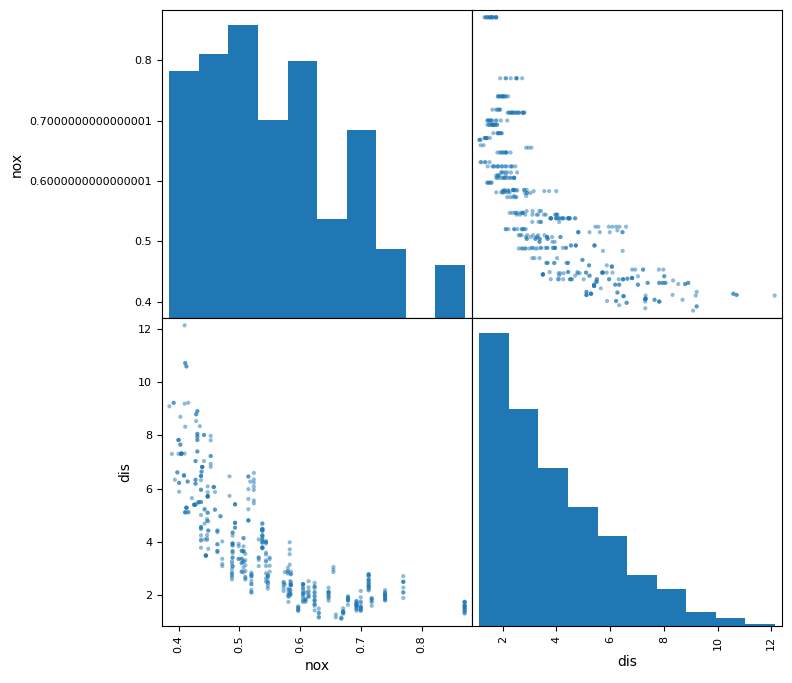

In [121]:
pd.plotting.scatter_matrix(Boston[['nox', 'dis']],figsize=(8,8));

In [122]:
X = Boston.drop(columns=['nox'])
y = Boston['nox']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=0.2, random_state=42)

## (a) ##
Use the poly() function from the ISLP.models module to fit a
cubic polynomial regression to predict nox using dis. Report the
regression output, and plot the resulting data and polynomial
fits.

In [123]:
transformador_poly_cubico = ModelSpec([poly('dis',3)]).fit(X_treino)
modelo_poly_cubico = OLS(y_treino, transformador_poly_cubico.transform(X_treino)).fit()
modelo_poly_cubico.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     80.86
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.73e-26
Time:                        10:42:59   Log-Likelihood:                 139.18
No. Observations:                 101   AIC:                            -270.4
Df Residuals:                      97   BIC:                            -259.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0.5560      0.006     89.780      0.000       0.544       0.568
poly(dis, degree=3)[0]    -0.8973      0.062    -14.417      0.000      -1.021      -0.774
poly(dis, degree=3)[1]     0.3638      0.062      5.845      0.000       0.240       0.487
poly(dis, degree=3)[2]    -0.0466      0.062     -0.749      0.456      -0.170       0.077
==============================================================================
Omnibus:                        8.095   Durbin-Watson:                   2.297
Prob(Omnibus):                  0.017   Jarque-Bera (JB):                7.756
Skew:                           0.651   Prob(JB):                       0.0207
Kurtosis:                       3.388   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

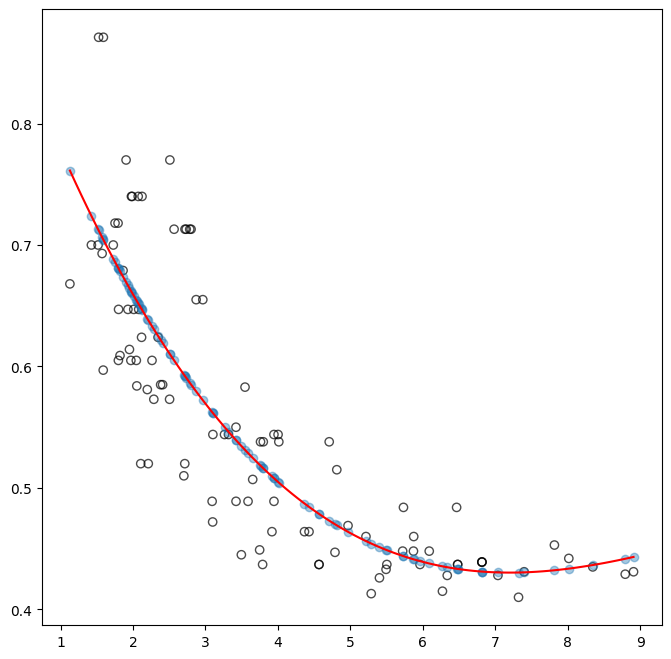

In [124]:
modelo_poly_cubico_predicao_treino = modelo_poly_cubico.predict(transformador_poly_cubico.transform(X_treino))
modelo_poly_cubico_predicao_teste = modelo_poly_cubico.predict(transformador_poly_cubico.transform(X_teste))
dis_seq = np.linspace(X_treino['dis'].min(), X_treino['dis'].max(), 100)
dis_seq_df = pd.DataFrame({'dis':dis_seq})

ax = subplots(figsize=(8,8))[1]
ax.scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax.scatter(X_treino['dis'], modelo_poly_cubico_predicao_treino, alpha=0.4)
ax.plot(dis_seq_df.values, modelo_poly_cubico.predict(transformador_poly_cubico.transform(dis_seq_df)), color='r');

## (b) ## 
Plot the polynomial fits for a range of different polynomial
degrees (say, from 1 to 10), and report the associated residual
sum of squares.

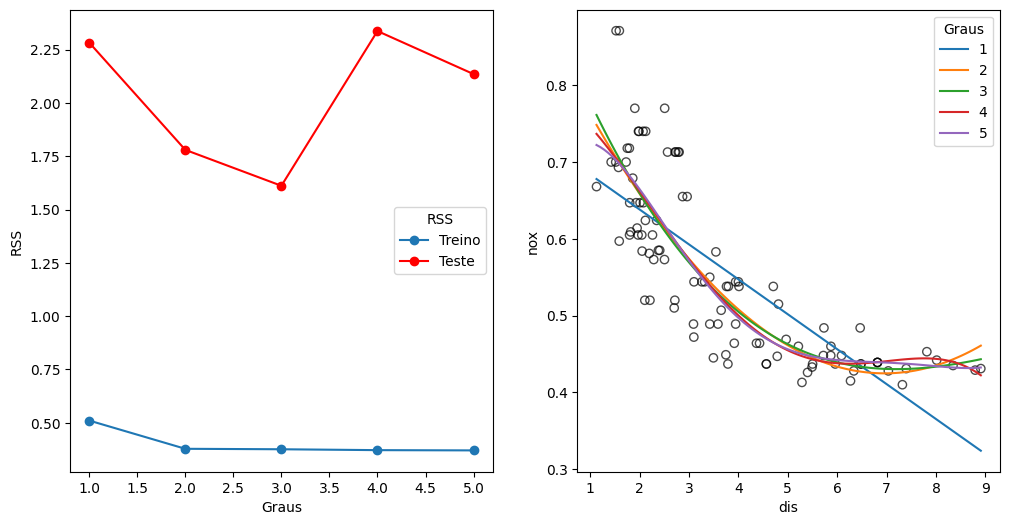

In [132]:
graus_polinomios = range(1, 6)
ax = subplots(1,2,figsize=(12,6))[1]

transformadores_poly = [ModelSpec([poly('dis', degree=grau)]).fit(X_treino) for grau in graus_polinomios]
X_treinos_poly = [transformador.transform(X_treino) for transformador in transformadores_poly]
modelos_poly = [OLS(y_treino, _X_treino).fit() for _X_treino in X_treinos_poly]

y_predicoes_treino_poly = [modelo.predict(transformador.transform(X_treino)) for modelo, transformador in zip(modelos_poly, transformadores_poly)] 
rss_treinos_poly = [np.sum((_y_predicao - y)**2) for _y_predicao in y_predicoes_treino_poly]

y_predicoes_teste_poly = [modelo.predict(transformador.transform(X_teste)) for modelo, transformador in zip (modelos_poly, transformadores_poly)]
rss_teste_poly = [np.sum((_y_predicao - y_teste)**2) for _y_predicao in y_predicoes_teste_poly]

ax[0].plot(graus_polinomios, rss_treinos_poly, '-o', label='Treino')
ax[0].plot(graus_polinomios, rss_teste_poly, 'r-o', label='Teste')
ax[0].set_ylim((min(rss_treinos_poly)-.1, max(rss_teste_poly)+.1))
ax[0].set_xlabel('Graus')
ax[0].set_ylabel('RSS')

ax[1].scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax[1].set_xlabel('dis')
ax[1].set_ylabel('nox')
for modelo, transformador, grau in zip(modelos_poly, transformadores_poly, graus_polinomios):
    ax[1].plot(dis_seq, modelo.predict(transformador.transform(dis_seq_df)), label=grau)
ax[0].legend(title='RSS')
ax[1].legend(title='Graus');


## (c) ## 
Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.

In [ ]:
anova_lm(*modelos_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,99.0,0.510303,0.0,NaN,NaN,NaN
1,98.0,0.377954,1.0,0.132349,33.939441,7.244636e-08
2,97.0,0.375780,1.0,0.002174,0.557515,4.570692e-01
3,96.0,0.371641,1.0,0.004139,1.061385,3.054881e-01
4,95.0,0.370458,1.0,0.001183,0.303469,5.830092e-01


In [ ]:
cv_scores = [np.mean(
                    cross_validate(sklearn_sm(OLS, ModelSpec([poly('dis',grau)])),
                                   X_treino,
                                   y_treino,
                                   cv=5)['test_score']
                    )
                    for grau in graus_polinomios
            ]
df_cv_scores = pd.DataFrame(cv_scores,
                            index=graus_polinomios,
                            columns=['cv_score'])
df_cv_scores

,cv_score
1,0.005143
2,0.003827
3,0.003803
4,0.003823
5,0.003862


## (d) ## 
Use the bs() function from the ISLP.models module to fit a re
gression spline to predict nox using dis. Report the output for
the fit using four degrees of freedom. How did you choose the
knots? Plot the resulting fit.

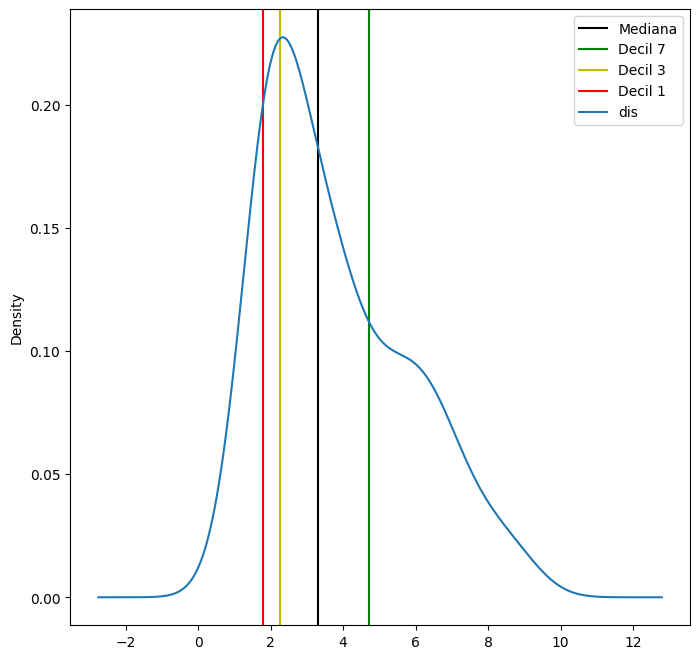

In [ ]:
nos = [{'nome': 'Mediana', 'valor':X_treino.dis.quantile(.5), 'cor':'k'}, 
       {'nome': 'Decil 7', 'valor':X_treino.dis.quantile(.7), 'cor':'g'}, 
       {'nome': 'Decil 3', 'valor':X_treino.dis.quantile(.3), 'cor':'y'},
       {'nome': 'Decil 1', 'valor':X_treino.dis.quantile(.1), 'cor':'r'},]
ax = subplots(figsize=(8,8))[1]
for no in nos:
    ax.axvline(no['valor'], label=no['nome'], c=no['cor'])
X_treino.dis.plot.density(ax=ax)
ax.legend();

In [ ]:
transformadores_bs_manual = [ModelSpec([bs('dis', internal_knots=[no['valor']])]).fit(X_treino) for no in nos]
modelos_bs_manual = [OLS(y_treino, transformador.transform(X_treino)).fit() for transformador in transformadores_bs_manual]
modelos_bs_manual_predicao_treino = [modelo.predict(transformador.transform(X_treino)) for modelo, transformador in zip(modelos_bs_manual,transformadores_bs_manual)]
rss_treino_bs_manual = [np.sum((predicao - y_treino)**2) for predicao in modelos_bs_manual_predicao_treino]

modelos_bs_manual_predicao_teste = [modelo.predict(transformador.transform(X_teste)) for modelo, transformador in zip(modelos_bs_manual,transformadores_bs_manual)]
rss_teste_bs_manual = [np.sum((predicao - y_teste)**2) for predicao in modelos_bs_manual_predicao_teste]

rss_treino_bs_manual, rss_teste_bs_manual


([np.float64(0.3705351667141839),
  np.float64(0.3714292983793608),
  np.float64(0.371628250300528),
  np.float64(0.3666104546646634)],
 [np.float64(1.6005814994344696),
  np.float64(1.7823224486379425),
  np.float64(1.5337460912906846),
  np.float64(1.515155512777363)])

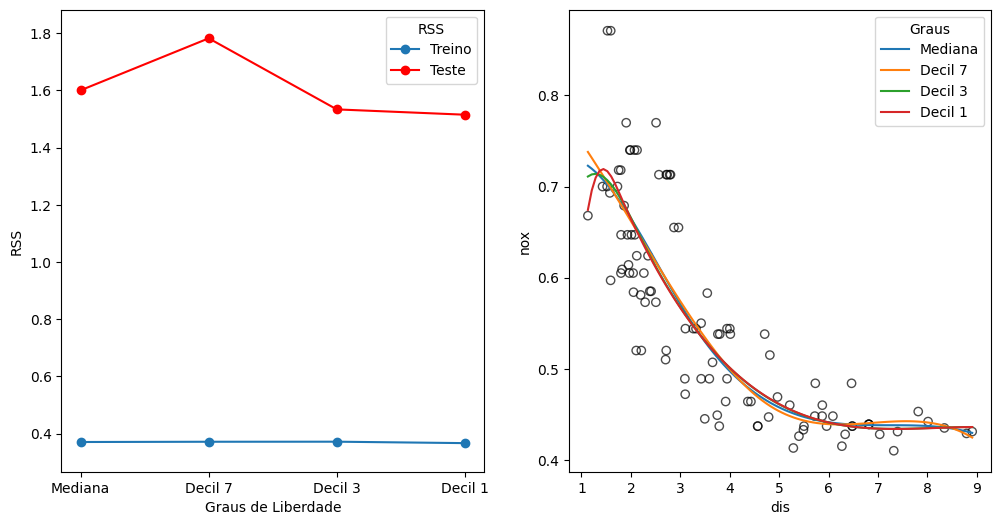

In [ ]:
ax = subplots(1,2,figsize=(12, 6))[1]
nomes_nos = []
for no in nos:
    nomes_nos.append(no["nome"])
ax[0].plot(nomes_nos, rss_treino_bs_manual, '-o', label='Treino')
ax[0].plot(nomes_nos, rss_teste_bs_manual, 'r-o', label='Teste')
ax[0].set_ylim((min(rss_treino_bs_manual )-.1, max(rss_teste_bs_manual)+.1))
ax[0].set_xlabel('Graus de Liberdade')
ax[0].set_ylabel('RSS')

ax[1].scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax[1].set_xlabel('dis')
ax[1].set_ylabel('nox')
for modelo, transformador, no in zip(modelos_bs_manual, transformadores_bs_manual, nos):
    ax[1].plot(dis_seq, modelo.predict(transformador.transform(dis_seq_df)), label=no['nome'])
ax[0].legend(title='RSS')
ax[1].legend(title='Graus');

## (e) ## 
Now fit a regression spline for a range of degrees of freedom, and
plot the resulting fits and report the resulting RSS. Describe the
results obtained.

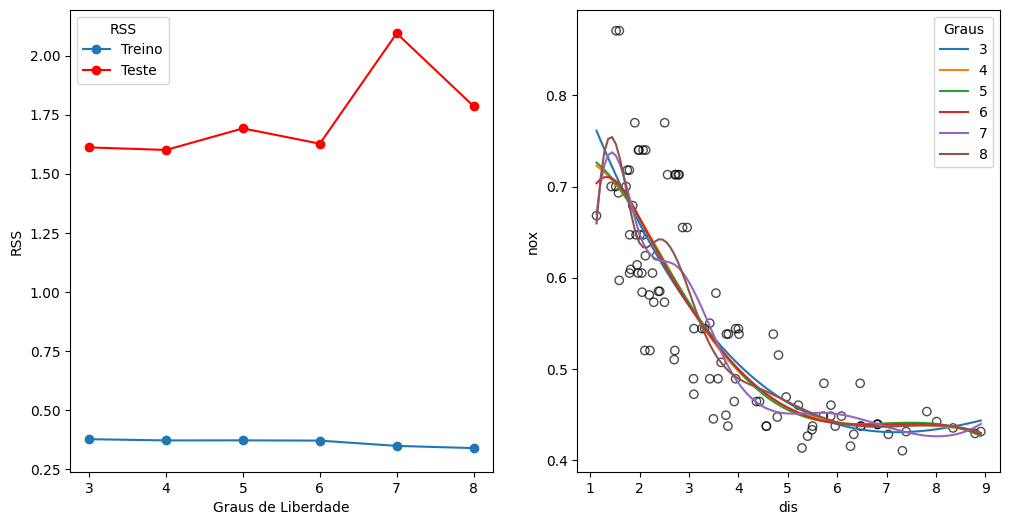

In [ ]:
graus_liberdade = range(3, 9)
ax = subplots(1,2,figsize=(12,6))[1]

transformadores_bs = [ModelSpec([bs('dis', df=grau)]).fit(X_treino) for grau in graus_liberdade]
X_treinos_bs = [transformador.transform(X_treino) for transformador in transformadores_bs]
modelos_bs = [OLS(y_treino, _X_treino).fit() for _X_treino in X_treinos_bs]

y_predicoes_treino_bs = [modelo.predict(transformador.transform(X_treino)) for modelo, transformador in zip(modelos_bs, transformadores_bs)] 
rss_treinos_bs = [np.sum((_y_predicao - y)**2) for _y_predicao in y_predicoes_treino_bs]

y_predicoes_teste_bs = [modelo.predict(transformador.transform(X_teste)) for modelo, transformador in zip (modelos_bs, transformadores_bs)]
rss_teste_bs = [np.sum((_y_predicao - y_teste)**2) for _y_predicao in y_predicoes_teste_bs]

ax[0].plot(graus_liberdade, rss_treinos_bs, '-o', label='Treino')
ax[0].plot(graus_liberdade, rss_teste_bs, 'r-o', label='Teste')
ax[0].set_ylim((min(rss_treinos_bs)-.1, max(rss_teste_bs)+.1))
ax[0].set_xlabel('Graus de Liberdade')
ax[0].set_ylabel('RSS')

ax[1].scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax[1].set_xlabel('dis')
ax[1].set_ylabel('nox')
for modelo, transformador, grau in zip(modelos_bs, transformadores_bs, graus_liberdade):
    ax[1].plot(dis_seq, modelo.predict(transformador.transform(dis_seq_df)), label=grau)
ax[0].legend(title='RSS')
ax[1].legend(title='Graus');

## (f) ## 
Perform cross-validation or another approach in order to select
the best degrees of freedom for a regression spline on this data.
Describe your results.

In [ ]:
anova_lm(*modelos_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,99.0,0.510303,0.0,NaN,NaN,NaN
1,98.0,0.377954,1.0,0.132349,33.939441,7.244636e-08
2,97.0,0.375780,1.0,0.002174,0.557515,4.570692e-01
3,96.0,0.371641,1.0,0.004139,1.061385,3.054881e-01
4,95.0,0.370458,1.0,0.001183,0.303469,5.830092e-01


In [ ]:
cv_scores = [np.mean(
                    cross_validate(sklearn_sm(OLS, ModelSpec([bs('dis',df=grau)])),
                                   X_treino,
                                   y_treino,
                                   cv=5)['test_score']
                    )
                    for grau in graus_liberdade
            ]
df_cv_scores = pd.DataFrame(cv_scores,
                            index=graus_liberdade,
                            columns=['cv_score'])
df_cv_scores

,cv_score
3,0.003803
4,0.003828
5,0.004001
6,0.004359
7,0.003883
8,0.003795
